<a href="https://colab.research.google.com/github/Hema-14052005/Hema-14052005/blob/main/fertilizer_suggestion_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy pandas matplotlib scikit-learn tensorflow torchvision pillow


# **Loading The Dataset & Displaying All Classes**

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import zipfile

# Unzip the dataset using Python's zipfile module for better error handling
zip_file_path = '/content/archive.zip'
extract_to_path = '/content/'

if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to_path)
        print(f"Successfully unzipped {zip_file_path} to {extract_to_path}")
    except zipfile.BadZipFile:
        print(f"Error: {zip_file_path} is not a valid zip file or is corrupted. Please ensure you have uploaded a valid zip file.")
        raise # Re-raise to stop execution and alert the user
    except Exception as e:
        print(f"An unexpected error occurred during unzipping: {e}")
        raise # Re-raise to stop execution and alert the user
else:
    print(f"Error: Zip file not found at {zip_file_path}. Please ensure the file is uploaded and named 'archive.zip'.")
    raise FileNotFoundError(f"Zip file not found at {zip_file_path}")

# Define the dataset paths
data_dir = "/content/rice_leaf_diseases_dataset"

# --- BEGIN: Debugging step to inspect directory structure ---
print(f"Listing contents of {data_dir}:")
!ls -R {data_dir}
# --- END: Debugging step ---

# Define image transformations (resize, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 for ResNet
    transforms.ToTensor(),         # Convert to Tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize for ResNet
])

# Load the full dataset (assuming all images are directly under data_dir, categorized by disease)
full_dataset = datasets.ImageFolder(data_dir, transform=transform)

# Get class names from the full dataset before splitting
class_names = full_dataset.classes

# Split the dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))  # 80% for training
valid_size = len(full_dataset) - train_size # Remaining for validation
train_dataset, valid_dataset = torch.utils.data.random_split(full_dataset, [train_size, valid_size])

# DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# Check class names and dataset sizes
print(f"Classes: {class_names}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(valid_dataset)}")

# Note: The original 'test_dir' was not used for ImageFolder loading
# and is not explicitly present in the unzipped structure for a split.
# If a separate test set is required, it would need to be created or loaded differently.

Successfully unzipped /content/archive.zip to /content/
Listing contents of /content/rice_leaf_diseases_dataset:
/content/rice_leaf_diseases_dataset:
'Bacterial leaf blight'   Blast  'Brown spot'  'Leaf smut'   Tungro

'/content/rice_leaf_diseases_dataset/Bacterial leaf blight':
DSC_0365.JPG  DSC_0395.JPG  IMG_0946.jpg  IMG_0991.jpg	IMG_1027.jpg
DSC_0366.jpg  DSC_0396.JPG  IMG_0947.jpg  IMG_0992.jpg	IMG_1029.jpg
DSC_0367.JPG  DSC_0397.JPG  IMG_0948.jpg  IMG_0993.jpg	IMG_1030.jpg
DSC_0370.jpg  DSC_0398.JPG  IMG_0949.jpg  IMG_0998.jpg	IMG_1031.jpg
DSC_0372.JPG  DSC_0399.JPG  IMG_0950.jpg  IMG_0999.jpg	IMG_1033.jpg
DSC_0373.JPG  DSC_0400.JPG  IMG_0952.jpg  IMG_1001.jpg	IMG_1034.jpg
DSC_0374.JPG  DSC_0401.JPG  IMG_0956.jpg  IMG_1002.jpg	IMG_1035.jpg
DSC_0375.JPG  DSC_0402.JPG  IMG_0959.jpg  IMG_1003.jpg	IMG_1036.jpg
DSC_0376.JPG  DSC_0403.JPG  IMG_0962.jpg  IMG_1004.jpg	IMG_1042.jpg
DSC_0377.JPG  DSC_0404.JPG  IMG_0964.jpg  IMG_1008.jpg	IMG_1043.jpg
DSC_0378.JPG  DSC_0405.JPG  IMG_0965.jpg

# **Loading Architecture, Architecture: RESNET18**

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18
from tqdm import tqdm  # For progress bars during training

# Load pre-trained ResNet
model = resnet18(pretrained=True)

# Freeze earlier layers for transfer learning
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to CPU
device = torch.device("cpu")
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Print the model architecture
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# **Training & Validation With Plotting**

In [ ]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses, valid_losses = [], []
    train_accuracies, valid_accuracies = [], []
    best_accuracy = 0.0

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()  # Set the model to training mode

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Training accuracy
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        # Calculate average training loss and accuracy
        train_loss = running_loss / len(train_loader)
        train_accuracy = correct_train / total_train * 100
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validation phase
        model.eval()  # Set the model to evaluation mode
        valid_loss = 0.0
        correct_valid = 0
        total_valid = 0

        with torch.no_grad():
            for images, labels in tqdm(valid_loader):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()

                # Validation accuracy
                _, preds = torch.max(outputs, 1)
                correct_valid += (preds == labels).sum().item()
                total_valid += labels.size(0)

        # Calculate average validation loss and accuracy
        valid_loss = valid_loss / len(valid_loader)
        valid_accuracy = correct_valid / total_valid * 100
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)

        print(f"Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")
        print(f"Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {valid_accuracy:.2f}%")

        # Save the best model
        if valid_accuracy > best_accuracy:
            best_accuracy = valid_accuracy
            torch.save(model.state_dict(), "best_resnet_model.pth")
            print("Saved the best model so far!")

    print("Training complete.")

    # Plot the accuracy graph
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(valid_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    return train_losses, valid_losses, train_accuracies, valid_accuracies

Epoch 1/10


100%|██████████| 4/4 [00:13<00:00,  3.40s/it]


Train Loss: 1.3413, Validation Loss: 1.1190
Train Accuracy: 42.22%, Validation Accuracy: 55.14%
Saved the best model so far!
Epoch 2/10


100%|██████████| 4/4 [00:13<00:00,  3.39s/it]


Train Loss: 0.8809, Validation Loss: 0.7944
Train Accuracy: 69.81%, Validation Accuracy: 79.44%
Saved the best model so far!
Epoch 3/10


...

Train Loss: 0.2954, Validation Loss: 0.3955
Train Accuracy: 92.92%, Validation Accuracy: 88.79%
Saved the best model so far!
Epoch 9/10


100%|██████████| 4/4 [00:13<00:00,  3.39s/it]


Train Loss: 0.2855, Validation Loss: 0.3734
Train Accuracy: 92.22%, Validation Accuracy: 88.79%
Epoch 10/10


100%|██████████| 4/4 [00:13<00:00,  3.38s/it]

Train Loss: 0.2389, Validation Loss: 0.3602
Train Accuracy: 95.05%, Validation Accuracy: 87.85%
Training complete.


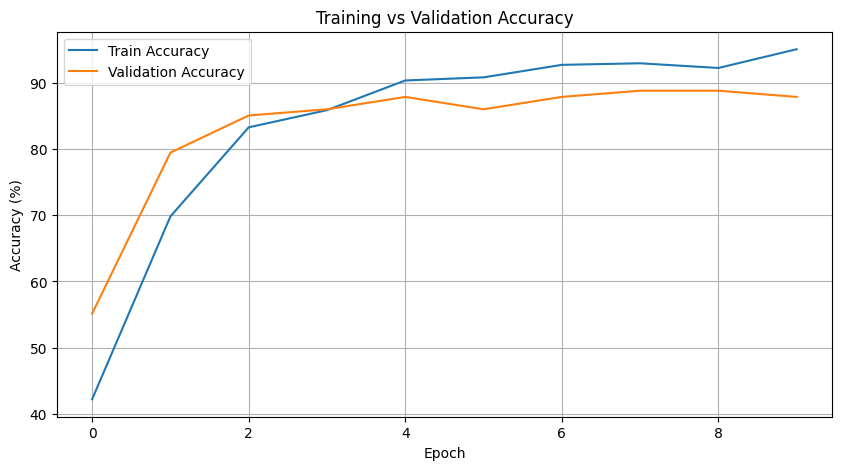

In [ ]:
epochs = 10

# Train the model and get results
train_losses, valid_losses, train_accuracies, valid_accuracies = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=epochs
)

#**Map Disease Classes To Fertilizer Suggestions**

In [ ]:
fertilizer_suggestions = {

    "Bacterial_leaf_blight":
    "Apply nitrogen in split doses and use potassium-rich fertilizers to improve disease resistance. Avoid excessive nitrogen application and maintain proper field drainage. Natural remedy: Spray diluted neem oil or garlic extract weekly. (பாக்டீரியா இலை கருகல்)",

    "Blast":
    "Use silicon-rich fertilizers along with balanced NPK fertilizers. Apply potassium to strengthen plant immunity and avoid excess urea application. Natural remedy: Spray neem oil and maintain proper spacing for airflow. (பிளாஸ்ட் நோய்)",

    "Brown_spot":
    "Apply balanced NPK fertilizer with sufficient potassium and phosphorus. Use zinc sulfate if zinc deficiency is observed in the soil. Natural remedy: Apply compost and panchagavya spray to improve plant health. (பழுப்பு புள்ளி நோய்)",

    "Leaf_smut":
    "Use balanced fertilizers with proper nitrogen and potassium levels. Avoid excessive nitrogen fertilization and maintain proper spacing between plants. Natural remedy: Spray turmeric extract mixed with water to reduce fungal spread. (இலை கரி நோய்)",

    "Tungro":
    "Apply balanced NPK fertilizers and zinc supplements to support healthy plant growth. Control insect vectors such as green leafhoppers using recommended pesticides. Natural remedy: Use neem cake and neem oil spray to control insects naturally. (துங்க்ரோ நோய்)",

    "Healthy":
    "Maintain proper fertilization with nitrogen, phosphorus, potassium, and micronutrients like zinc for healthy rice growth. Add organic compost and farmyard manure regularly. (ஆரோக்கியமான நெல் இலை)"
}

# **Test The Model**

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch # Ensure torch is imported here

def test_image_with_display(model, image_path, classes, transform, suggestions):
    """
    Predicts the disease from an image path, provides fertilizer suggestions,
    and displays the image being tested.

    Args:
        model: Trained PyTorch model.
        image_path: Path to the input image.
        classes: List of class names.
        transform: Preprocessing transform for the input image.
        suggestions: Dictionary with class names as keys and fertilizer suggestions as values.

    Returns:
        Predicted class and corresponding fertilizer suggestion.
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")

    # Display the image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title("Image Being Tested")
    plt.axis("off")
    plt.show()

    # Preprocess the image
    processed_image = transform(image).unsqueeze(0)  # Add batch dimension

    # Set the model to evaluation mode
    model.eval()

    # Predict the class
    with torch.no_grad():
        outputs = model(processed_image.to(device))
        print(f"Model outputs (logits): {outputs}") # Debug: print model outputs
        _, predicted = torch.max(outputs, 1)
        # --- DEBUG PRINTS ---
        print(f"Predicted tensor: {predicted}")
        print(f"Predicted item: {predicted.item()}")
        print(f"Number of classes in 'classes' list: {len(classes)}")
        # --- END DEBUG PRINTS ---
        predicted_class = classes[predicted.item()]

    # Normalize the predicted class name for dictionary lookup
    normalized_predicted_class = predicted_class.replace(" ", "_")

    # Check if the class is healthy
    if "healthy" in normalized_predicted_class.lower():
        suggestion = "Healthy: No fertilizer needed right now."
    else:
        suggestion = suggestions.get(normalized_predicted_class, "No suggestion available.")

    return predicted_class, suggestion

In [ ]:
import os

# List the contents of the test directory to find an example image
# Correcting 'test_dir' to 'data_dir' as the dataset was unzipped there
print(f"Contents of data directory: {data_dir}")
for root, dirs, files in os.walk(data_dir):
    for name in files:
        if name.lower().endswith(('.png', '.jpg', '.jpeg')):
            print(os.path.join(root, name))
            break # Print only the first image found in the test set
    if files: # If a file was found in the current root, break after printing one
        break

Contents of data directory: /content/rice_leaf_diseases_dataset
/content/rice_leaf_diseases_dataset/Blast/IMG_0572.jpg


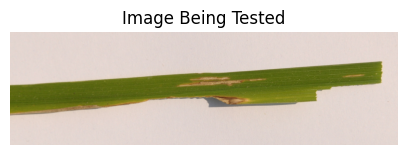

Model outputs (logits): tensor([[-0.7718, -0.9531, -0.3258, -0.1699,  0.4622]])
Predicted tensor: tensor([4])
Predicted item: 4
Number of classes in 'classes' list: 5
Disease Detected: Tungro
Suggestion: Apply balanced NPK fertilizers and zinc supplements to support healthy plant growth. Control insect vectors such as green leafhoppers using recommended pesticides. Natural remedy: Use neem cake and neem oil spray to control insects naturally. (துங்க்ரோ நோய்)


In [ ]:
# Correct the file path to an image available in the Colab environment
test_image_path = "/content/rice_leaf_diseases_dataset/Bacterial leaf blight/DSC_0365.JPG"

# Predict the disease, get the fertilizer suggestion, and display the image
predicted_class, suggestion = test_image_with_display(
    model, test_image_path, class_names, transform, fertilizer_suggestions
)

print(f"Disease Detected: {predicted_class}")
print(f"Suggestion: {suggestion}")